# ResNet com TensorFlow

Este exemplo demonstra a construção e treinamento de um modelo ResNet simplificado usando TensorFlow e o conjunto de dados CIFAR-10.

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models, datasets
import numpy as np
import matplotlib.pyplot as plt

### 1. Carregar e Pré-processar o Conjunto de Dados CIFAR-10

O CIFAR-10 consiste em 60.000 imagens coloridas de 32x32 em 10 classes, com 6.000 imagens por classe. Existem 50.000 imagens de treinamento e 10.000 imagens de teste.

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1166s 7us/step
Formato dos dados de treinamento: (50000, 32, 32, 3)
Formato dos rótulos de treinamento: (50000, 10)
Formato dos dados de teste: (10000, 32, 32, 3)
Formato dos rótulos de teste: (10000, 10)


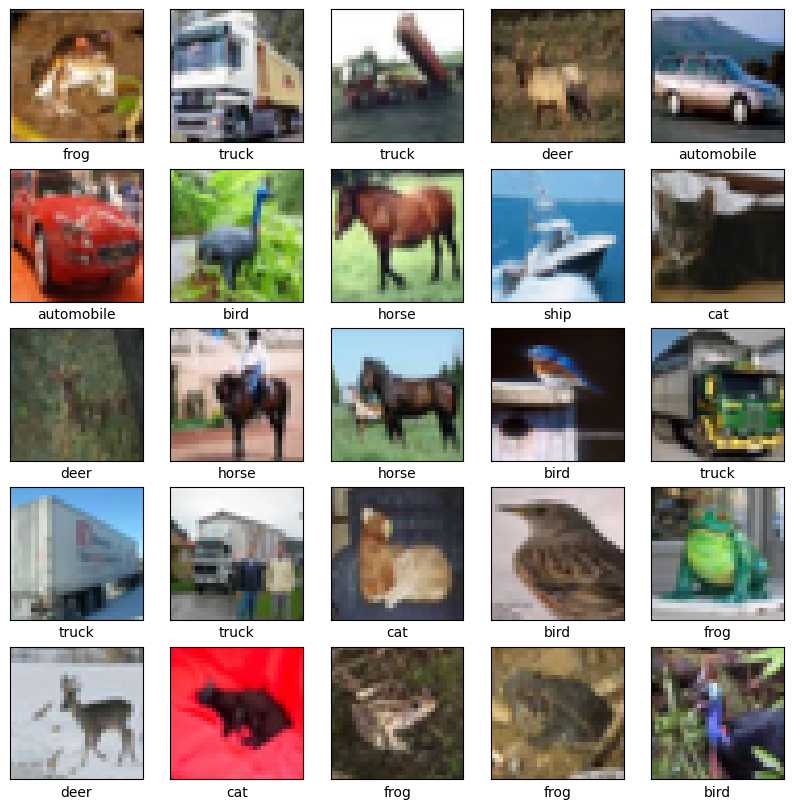

In [3]:
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

# Normalizar os valores dos pixels para o intervalo [0, 1]
train_images = train_images.astype('float32') / 255.0
test_images = test_images.astype('float32') / 255.0

# Converter rótulos para categorização one-hot
train_labels = tf.keras.utils.to_categorical(train_labels, 10)
test_labels = tf.keras.utils.to_categorical(test_labels, 10)

print(f"Formato dos dados de treinamento: {train_images.shape}")
print(f"Formato dos rótulos de treinamento: {train_labels.shape}")
print(f"Formato dos dados de teste: {test_images.shape}")
print(f"Formato dos rótulos de teste: {test_labels.shape}")


class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i])
    plt.xlabel(class_names[np.argmax(train_labels[i])])
plt.show()

### 2. Definir um Bloco de ResNet

Uma parte fundamental da ResNet é o bloco residual, que permite que a rede aprenda funções de identidade, ajudando a mitigar o problema do gradiente evanescente/explosivo em redes muito profundas.

In [4]:
def res_block(x, filters, kernel_size=(3, 3), stride=1, conv_shortcut=True, name=None):
    shortcut = x
    x = layers.Conv2D(filters, kernel_size, strides=stride, padding='same', name=f'{name}_conv1')(x)
    x = layers.BatchNormalization(name=f'{name}_bn1')(x)
    x = layers.ReLU(name=f'{name}_relu1')(x)
    x = layers.Conv2D(filters, kernel_size, padding='same', name=f'{name}_conv2')(x)
    x = layers.BatchNormalization(name=f'{name}_bn2')(x)
    if conv_shortcut:
        shortcut = layers.Conv2D(filters, 1, strides=stride, name=f'{name}_shortcut_conv')(shortcut)
        shortcut = layers.BatchNormalization(name=f'{name}_shortcut_bn')(shortcut)
    x = layers.add([x, shortcut], name=f'{name}_add')
    x = layers.ReLU(name=f'{name}_out_relu')(x)
    return x

def build_resnet18(input_shape=(32, 32, 3), num_classes=10):
    inputs = layers.Input(shape=input_shape)
    x = layers.Conv2D(64, (3, 3), strides=(1, 1), padding='same', name='conv1')(inputs)
    x = layers.BatchNormalization(name='bn1')(x)
    x = layers.ReLU(name='relu1')(x)
    # ResNet Blocks
    x = res_block(x, 64, name='block1_1', conv_shortcut=False) # No shortcut conv needed for same dimensions
    x = res_block(x, 64, name='block1_2', conv_shortcut=False)
    # Block 2 (downsampling)
    x = res_block(x, 128, stride=2, name='block2_1') # Downsample with stride 2, need shortcut conv
    x = res_block(x, 128, name='block2_2', conv_shortcut=False)
    # Block 3 (downsampling)
    x = res_block(x, 256, stride=2, name='block3_1') # Downsample with stride 2, need shortcut conv
    x = res_block(x, 256, name='block3_2', conv_shortcut=False)
    # Block 4 (downsampling)
    x = res_block(x, 512, stride=2, name='block4_1') # Downsample with stride 2, need shortcut conv
    x = res_block(x, 512, name='block4_2', conv_shortcut=False)

    x = layers.GlobalAveragePooling2D(name='avg_pool')(x)
    outputs = layers.Dense(num_classes, activation='softmax', name='predictions')(x)

    model = models.Model(inputs, outputs, name='resnet18_cifar10')
    return model


model = build_resnet18()
model.summary()

Model: "resnet18_cifar10"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1 (Conv2D)      │ (None, 32, 32,    │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn1                 │ (None, 32, 32,    │        256 │ conv1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ relu1 (ReLU)        │ (None, 32, 32,    │          0 │ bn1[0][0]         │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_1_conv1      │ (None, 32, 32,    │     36,928 │ relu1[0][0]       │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_1_bn1        │ (None, 32, 32,    │        256 │ block1_1_conv1[0… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_1_relu1      │ (None, 32, 32,    │          0 │ block1_1_bn1[0][… │
│ (ReLU)              │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_1_conv2      │ (None, 32, 32,    │     36,928 │ block1_1_relu1[0… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_1_bn2        │ (None, 32, 32,    │        256 │ block1_1_conv2[0… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_1_add (Add)  │ (None, 32, 32,    │          0 │ block1_1_bn2[0][… │
│                     │ 64)               │            │ relu1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_1_out_relu   │ (None, 32, 32,    │          0 │ block1_1_add[0][… │
│ (ReLU)              │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_2_conv1      │ (None, 32, 32,    │     36,928 │ block1_1_out_rel… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_2_bn1        │ (None, 32, 32,    │        256 │ block1_2_conv1[0… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_2_relu1      │ (None, 32, 32,    │          0 │ block1_2_bn1[0][… │
│ (ReLU)              │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_2_conv2      │ (None, 32, 32,    │     36,928 │ block1_2_relu1[0… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_2_bn2        │ (None, 32, 32,    │        256 │ block1_2_conv2[0… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_2_add (Add)  │ (None, 32, 32,    │          0 │ block1_2_bn2[0][

 Total params: 11,188,362 (42.68 MB)

 Trainable params: 11,178,762 (42.64 MB)

 Non-trainable params: 9,600 (37.50 KB)

### 3. Compilar e Treinar o Modelo

Definiremos o otimizador, a função de perda e as métricas. Em seguida, treinaremos o modelo com os dados de treinamento.

In [5]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

checkpoint_filepath = 'best_resnet_cifar10.weights.h5'
model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_filepath,
    save_weights_only=True,
    monitor='val_accuracy',
    mode='max',
    save_best_only=True)

history = model.fit(train_images, train_labels,
                    epochs=10,
                    validation_data=(test_images, test_labels),
                    batch_size=64,
                    callbacks=[model_checkpoint_callback])

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 97s 87ms/step - accuracy: 0.5720 - loss: 1.1998 - val_accuracy: 0.4742 - val_loss: 1.9772
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 49s 63ms/step - accuracy: 0.7513 - loss: 0.7123 - val_accuracy: 0.6714 - val_loss: 0.9630
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 50s 64ms/step - accuracy: 0.8129 - loss: 0.5380 - val_accuracy: 0.7602 - val_loss: 0.7192
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 50s 65ms/step - accuracy: 0.8541 - loss: 0.4221 - val_accuracy: 0.7843 - val_loss: 0.6541
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 51s 65ms/step - accuracy: 0.8849 - loss: 0.3273 - val_accuracy: 0.7884 - val_loss: 0.6837
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 51s 65ms/step - accuracy: 0.9117 - loss: 0.2499 - val_accuracy: 0.7944 - val_loss: 0.6562
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 51s 65ms/step - accuracy: 0.9375 - loss: 0.1771 - val_accuracy: 0.7766 - val_loss: 0.8080
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 51s 65ms/step - accuracy: 0.9541 - loss: 0.1323 - 

### 4. Avaliar o Modelo

Vamos visualizar o desempenho do modelo no conjunto de teste e plotar o histórico de treinamento.

313/313 - 5s - 18ms/step - accuracy: 0.8299 - loss: 0.6354

Acurácia do modelo no conjunto de teste: 0.8299


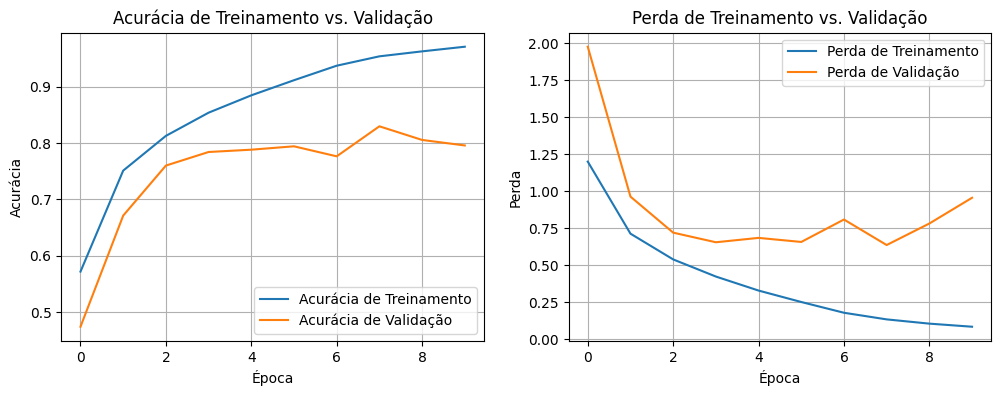

In [6]:
model.load_weights(checkpoint_filepath)
loss, accuracy = model.evaluate(test_images, test_labels, verbose=2)
print(f"\nAcurácia do modelo no conjunto de teste: {accuracy:.4f}")


plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Acurácia de Treinamento')
plt.plot(history.history['val_accuracy'], label='Acurácia de Validação')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.title('Acurácia de Treinamento vs. Validação')
plt.legend()
plt.grid(True)
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Perda de Treinamento')
plt.plot(history.history['val_loss'], label='Perda de Validação')
plt.xlabel('Época')
plt.ylabel('Perda')
plt.title('Perda de Treinamento vs. Validação')
plt.legend()
plt.grid(True)
plt.show()

# Exemplo de uso de ResNet50 pré-treinada diretamente do `tf.keras.applications`

Quando se utiliza modelos pré-treinados como o ResNet50, geralmente se remove a camada de classificação original (superior) e adiciona-se novas camadas adaptadas ao número de classes do novo conjunto de dados. Além disso, a ResNet50 pré-treinada espera imagens de 224x224 pixels, enquanto o CIFAR-10 possui imagens de 32x32. Portanto, seria necessário um pré-processamento para redimensionar as imagens ou treinar as camadas convolucionais do ResNet50 do zero com o novo `input_shape`.

### 5. Ajuste Fino (Fine-Tuning) da ResNet50 no CIFAR-10

Para aplicar transferência de aprendizado com sintonia fina (fine-tuning) utilizando a ResNet50, realizamos os seguintes passos:
1. Adicionamos uma camada para redimensionar as imagens de 32x32 para 224x224.
2. Descongelamos as últimas camadas da ResNet50 base para que seus pesos sejam suavemente ajustados.
3. Compilamos o modelo com uma taxa de aprendizado (learning rate) reduzida para evitar destruir os pesos pré-treinados já consolidados.

In [8]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Input, Dense, GlobalAveragePooling2D, UpSampling2D
from tensorflow.keras.models import Model

# Definir a entrada com o formato original do CIFAR-10
inputs = Input(shape=(32, 32, 3))

# Redimensionar as imagens para 224x224 (tamanho ideal para a ResNet50)
x = UpSampling2D(size=(7, 7))(inputs)  # 32 * 7 = 224

# Carregar a ResNet50 sem a camada de classificação do ImageNet
base_model = ResNet50(weights='imagenet', include_top=False, input_tensor=x)

# Descongelar as camadas superiores do modelo base para o Fine-Tuning
# Vamos congelar a maior parte do modelo e deixar apenas os blocos finais treináveis
base_model.trainable = True

# Número de camadas a congelar (congelamos as primeiras 140 camadas, por exemplo)
fine_tune_at = 140
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# Adicionar novas camadas de classificação no topo
x = base_model.output
x = GlobalAveragePooling2D(name='fine_tuning_avg_pool')(x)
x = Dense(256, activation='relu', name='fine_tuning_dense')(x)
predictions = Dense(10, activation='softmax', name='fine_tuning_predictions')(x)

# Instanciar o modelo final
model_fine_tuning = Model(inputs=inputs, outputs=predictions)

# Compilar o modelo com uma taxa de aprendizado baixa
model_fine_tuning.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # LR baixa para não destruir pesos pré-treinados
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_fine_tuning.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 224, 224,  │          0 │ input_layer_2[0]… │
│ (UpSampling2D)      │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ up_sampling2d[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c

 Total params: 24,114,826 (91.99 MB)

 Trainable params: 15,768,330 (60.15 MB)

 Non-trainable params: 8,346,496 (31.84 MB)

Como o redimensionamento de imagens para 224x224 exige muita memória RAM e GPU, é recomendado treinar com lotes menores (ex: `batch_size=32`) e menos épocas iniciais.

In [9]:
# Exemplo de execução do treinamento de Fine-Tuning (ajuste epochs/batch_size conforme seu ambiente de GPU)
history_fine_tuning = model_fine_tuning.fit(
    train_images,
    train_labels,
    epochs=3,  # Poucas épocas para demonstração rápida devido ao custo computacional do UpSampling
    validation_data=(test_images, test_labels),
    batch_size=32
)

Epoch 1/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 268s 155ms/step - accuracy: 0.4848 - loss: 1.4496 - val_accuracy: 0.5241 - val_loss: 1.3564
Epoch 2/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 228s 146ms/step - accuracy: 0.5817 - loss: 1.1826 - val_accuracy: 0.5729 - val_loss: 1.1995
Epoch 3/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 230s 147ms/step - accuracy: 0.6134 - loss: 1.0948 - val_accuracy: 0.6003 - val_loss: 1.1512


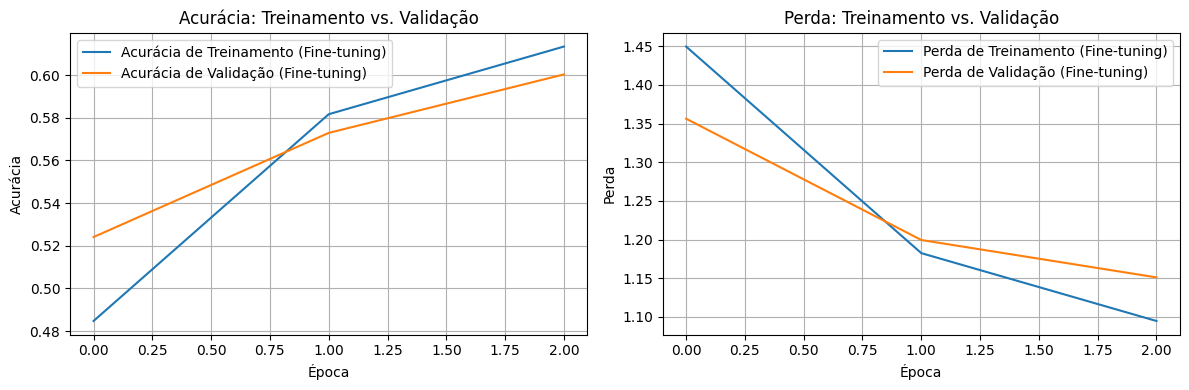

In [10]:

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_fine_tuning.history['accuracy'], label='Acurácia de Treinamento (Fine-tuning)')
plt.plot(history_fine_tuning.history['val_accuracy'], label='Acurácia de Validação (Fine-tuning)')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.title('Acurácia: Treinamento vs. Validação')
plt.legend()
plt.grid(True)
plt.subplot(1, 2, 2)
plt.plot(history_fine_tuning.history['loss'], label='Perda de Treinamento (Fine-tuning)')
plt.plot(history_fine_tuning.history['val_loss'], label='Perda de Validação (Fine-tuning)')
plt.xlabel('Época')
plt.ylabel('Perda')
plt.title('Perda: Treinamento vs. Validação')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()